# Diabetes — Model Evaluation
Deeper look at the saved model: ROC curve and feature
importance. These plots are also useful for your project
report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import roc_curve, roc_auc_score, classification_report

plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None


## 1. Load the saved model and test data

In [2]:
model = joblib.load("../../models/diabetes_model.pkl")

X_test = pd.read_csv("../../data/processed/diabetes_X_test.csv")
y_test = pd.read_csv("../../data/processed/diabetes_y_test.csv").squeeze()

print("Model type:", type(model).__name__)


Model type: RandomForestClassifier


## 2. Full classification report
Precision, recall, and F1 for both classes (0 = No diabetes,
1 = Diabetes).

In [3]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))


              precision    recall  f1-score   support

 No Diabetes       0.78      0.84      0.81       100
    Diabetes       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



## 3. ROC curve
Shows the trade-off between catching true positives and
raising false alarms, at every possible decision threshold.
A curve that hugs the top-left corner is better; the
diagonal line is what a random guess would look like.

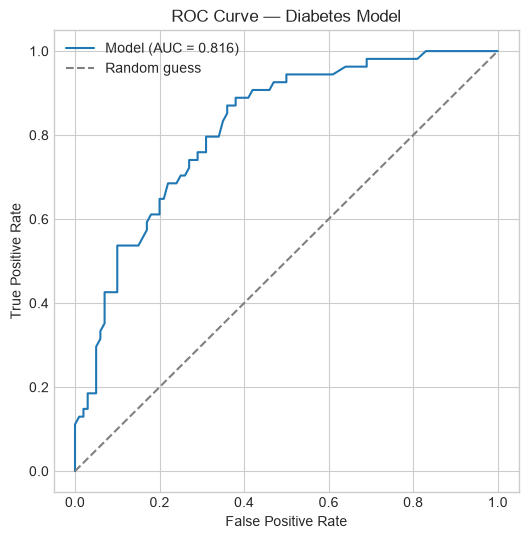

In [4]:
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Diabetes Model")
plt.legend()
plt.savefig("../../reports/figures/diabetes/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Feature importance
Which features drive the model's predictions most?
(Works directly for tree-based models like Random Forest /
XGBoost. For Logistic Regression, coefficients are used
instead — see the fallback below.)

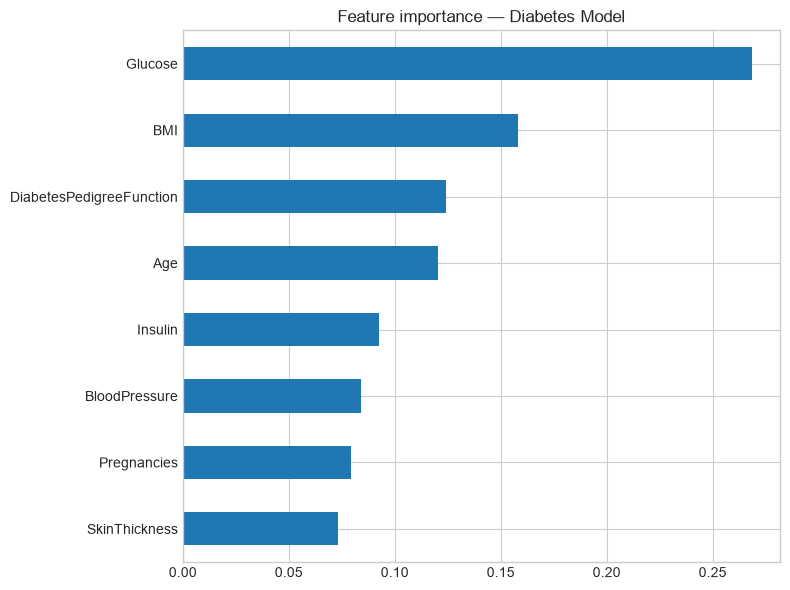

In [5]:
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
elif hasattr(model, "coef_"):
    importances = pd.Series(model.coef_[0], index=X_test.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=True)
    plt.figure(figsize=(8, 6))
    importances.plot(kind="barh")
    plt.title("Feature importance — Diabetes Model")
    plt.tight_layout()
    plt.savefig("../../reports/figures/diabetes/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("This model type doesn't expose feature importances directly.")


## 5. Confusion matrix heatmap
A visual version of the confusion matrix from the training
notebook — useful for your report.

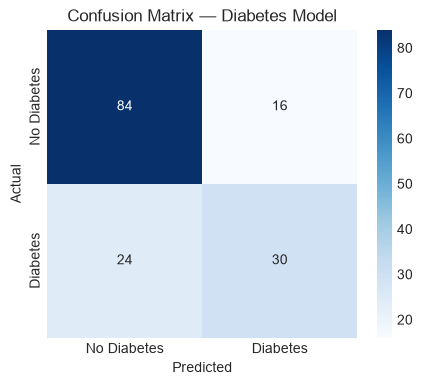

In [6]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Diabetes Model")
plt.savefig("../../reports/figures/diabetes/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


## Notes for your report
- AUC score: _fill in from the ROC curve above_
- Top 3 most important features: _fill in from step 4_
- Any concerning misclassifications: _look at the confusion matrix_

